In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from os.path import exists

In [2]:
pd.set_option('display.max_columns', None)

## Load and explore data

In [3]:
input_df = pd.read_csv('train.gz', compression='gzip', header=0, sep=',', quotechar='"')

In [4]:
input_df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ddd2926e,44956a24,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,96809ac8,711ee120,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b3cf8def,8a4875bd,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e8275b8f,6332421a,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,9644d0bf,779d90c2,1,0,18993,320,50,2161,0,35,-1,157


In [5]:
input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           object 
 6   site_domain       object 
 7   site_category     object 
 8   app_id            object 
 9   app_domain        object 
 10  app_category      object 
 11  device_id         object 
 12  device_ip         object 
 13  device_model      object 
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), object(9)
memory usage: 7.2+ GB


In [6]:
input_df = input_df[['id','click','hour']]

In [7]:
input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   id      float64
 1   click   int64  
 2   hour    int64  
dtypes: float64(1), int64(2)
memory usage: 925.3 MB


In [8]:
input_df['hour']=input_df['hour'].apply(lambda x: x + 2000000000)
input_df['datetime']=input_df['hour'].apply(lambda x: datetime.strptime(str(x), '%Y%m%d%H'))
input_df['hour_perday'] = input_df['datetime'].dt.hour

In [9]:
input_df['click'].value_counts()

0    33563901
1     6865066
Name: click, dtype: int64

In [10]:
len(input_df['id'].unique())==len(input_df)

True

## calculate and plot hourly click and impression time series

In [11]:
clicks_hourly = input_df.groupby(['datetime','hour_perday']).agg({'click':'sum'})
clicks_hourly

,,click
datetime,hour_perday,
2014-10-21 00:00:00,0,20792
2014-10-21 01:00:00,1,23873
2014-10-21 02:00:00,2,31265
2014-10-21 03:00:00,3,32830
2014-10-21 04:00:00,4,40026
...,...,...
2014-10-30 19:00:00,19,26046
2014-10-30 20:00:00,20,20820
2014-10-30 21:00:00,21,20958


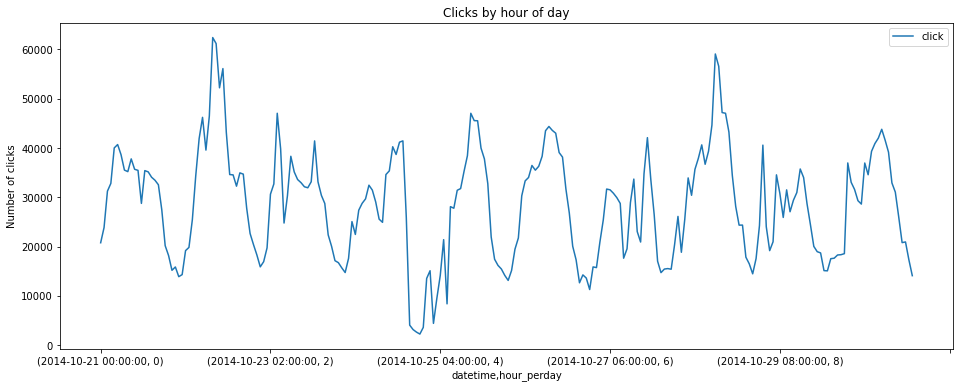

In [12]:
clicks_hourly.plot(figsize=(16,6))
plt.ylabel('Number of clicks')
plt.title('Clicks by hour of day');
plt.show()

In [13]:
impressions_hourly = input_df.groupby(['datetime','hour_perday']).agg({'id':'count'})
impressions_hourly

,,id
datetime,hour_perday,
2014-10-21 00:00:00,0,119006
2014-10-21 01:00:00,1,137442
2014-10-21 02:00:00,2,207471
2014-10-21 03:00:00,3,193355
2014-10-21 04:00:00,4,264711
...,...,...
2014-10-30 19:00:00,19,134243
2014-10-30 20:00:00,20,110764
2014-10-30 21:00:00,21,112238


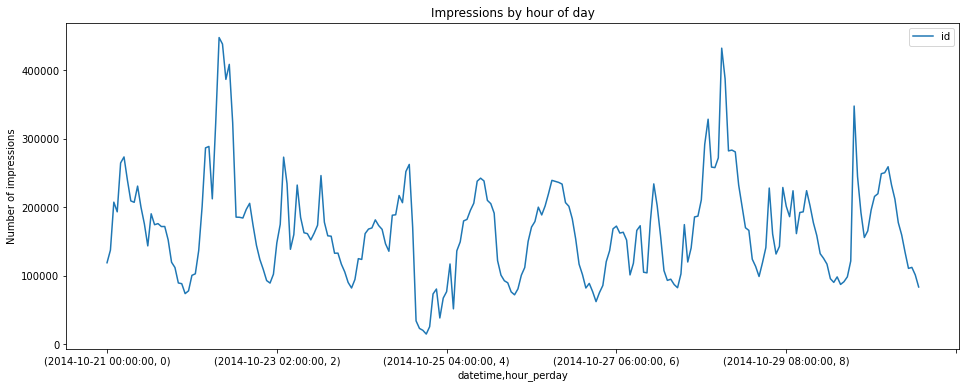

In [14]:
impressions_hourly.plot(figsize=(16,6))
plt.ylabel('Number of impressions')
plt.title('Impressions by hour of day');
plt.show()

## Calculate and plot hourly CTR time-series

In [15]:
ctr_df = input_df.groupby(['datetime','hour_perday']).agg({'click':'sum','id':'count'}).rename(columns={"id": "impressions","click": "clicks"})
ctr_df['hourly_ctr'] = ctr_df['clicks']/ctr_df['impressions']

In [16]:
ctr_df.head()

,,clicks,impressions,hourly_ctr
datetime,hour_perday,,,
2014-10-21 00:00:00,0,20792,119006,0.174714
2014-10-21 01:00:00,1,23873,137442,0.173695
2014-10-21 02:00:00,2,31265,207471,0.150696
2014-10-21 03:00:00,3,32830,193355,0.169791
2014-10-21 04:00:00,4,40026,264711,0.151206


In [17]:
ctr_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 240 entries, (Timestamp('2014-10-21 00:00:00'), 0) to (Timestamp('2014-10-30 23:00:00'), 23)
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   clicks       240 non-null    int64  
 1   impressions  240 non-null    int64  
 2   hourly_ctr   240 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 8.5 KB


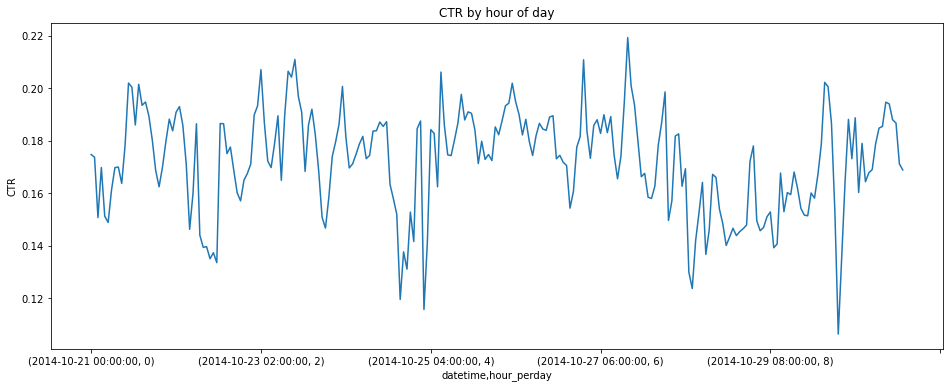

In [18]:
ctr_df['hourly_ctr'].plot(figsize=(16,6))
plt.ylabel('CTR')
plt.title('CTR by hour of day');
plt.show()

## Find and plot anomalies using exponential moving average

In [19]:
span = 4  # Specify decay in terms of span, α=2/(span+1), for span≥1.
mean = ctr_df['hourly_ctr'].ewm(span, adjust=False).mean()
std = ctr_df['hourly_ctr'].ewm(span, adjust=False).std()
std[0] = 0

mean_plus_std = mean + 1.5*std
mean_minus_std = mean - 1.5*std

In [20]:
is_outlier = (ctr_df['hourly_ctr']> mean_plus_std)|(ctr_df['hourly_ctr'] < mean_minus_std)
outliers = ctr_df[is_outlier]

In [21]:
outliers = outliers.reset_index().set_index('datetime')
outliers.index

DatetimeIndex(['2014-10-21 11:00:00', '2014-10-22 05:00:00',
               '2014-10-24 16:00:00', '2014-10-24 19:00:00',
               '2014-10-26 21:00:00', '2014-10-27 01:00:00',
               '2014-10-27 14:00:00', '2014-10-28 08:00:00',
               '2014-10-29 02:00:00', '2014-10-30 00:00:00',
               '2014-10-30 04:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

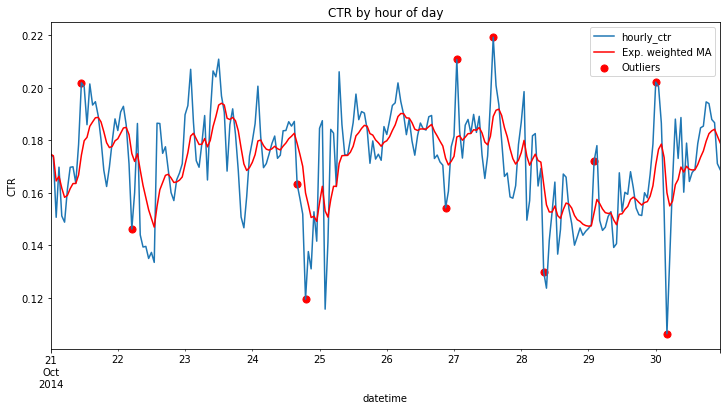

In [22]:
ctr_df.reset_index().set_index('datetime')['hourly_ctr'].plot(figsize=(12,6))
plt.ylabel('CTR')
plt.title('CTR by hour of day');
ctr_df.reset_index().set_index('datetime')['hourly_ctr'].ewm(span).mean().plot(figsize=(12,6), c = 'r', label = 'Exp. weighted MA')
plt.scatter(outliers.index, outliers['hourly_ctr'], c = 'r', marker = 'o', s = 50, label = 'Outliers')
plt.legend()

## BONUS: calculate and plot anomalies using LOESS 

In [23]:
from statsmodels.tsa.seasonal import STL

In [24]:
stl = STL(ctr_df.reset_index().set_index('datetime')['hourly_ctr'])
result = stl.fit()

In [25]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid

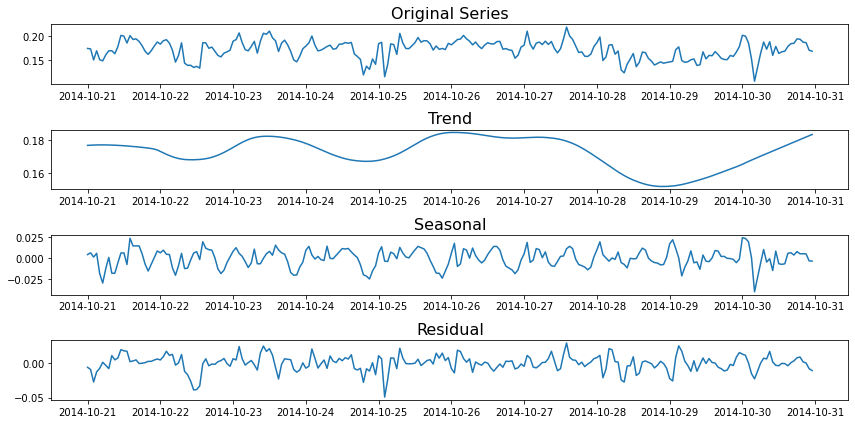

In [26]:
plt.figure(figsize=(12,6))

plt.subplot(4,1,1)
plt.plot(ctr_df.reset_index().set_index('datetime')['hourly_ctr'])
plt.title('Original Series', fontsize=16)

plt.subplot(4,1,2)
plt.plot(trend)
plt.title('Trend', fontsize=16)

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title('Seasonal', fontsize=16)

plt.subplot(4,1,4)
plt.plot(resid)
plt.title('Residual', fontsize=16)

plt.tight_layout()

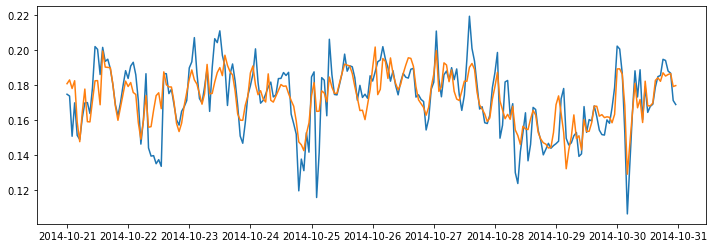

In [27]:
estimated = trend + seasonal
plt.figure(figsize=(12,4))
plt.plot(ctr_df.reset_index().set_index('datetime')['hourly_ctr'])
plt.plot(estimated)

In [28]:
resid_mu = resid.mean()
resid_dev = resid.std()

lower = resid_mu - 1.5*resid_dev
upper = resid_mu + 1.5*resid_dev

(16364.0, 16374.0)

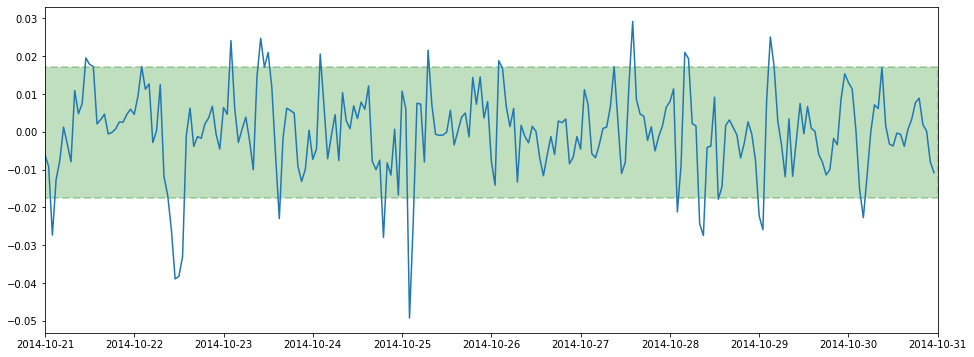

In [29]:
plt.figure(figsize=(16,6))
plt.plot(resid)

plt.fill_between([datetime(2014,10,21), datetime(2014,10,31)], lower, upper, color='g', alpha=0.25, linestyle='--', linewidth=2)
plt.xlim(datetime(2014,10,21), datetime(2014,10,31))

In [30]:
outliers = ctr_df.reset_index().set_index('datetime')['hourly_ctr'][(resid < lower) | (resid > upper)]

In [31]:
outliers

datetime
2014-10-21 02:00:00    0.150696
2014-10-21 11:00:00    0.201951
2014-10-21 12:00:00    0.200355
2014-10-21 13:00:00    0.185977
2014-10-22 02:00:00    0.192982
2014-10-22 10:00:00    0.139613
2014-10-22 11:00:00    0.135015
2014-10-22 12:00:00    0.137323
2014-10-22 13:00:00    0.133520
2014-10-23 02:00:00    0.207075
2014-10-23 10:00:00    0.206454
2014-10-23 12:00:00    0.210940
2014-10-23 15:00:00    0.168289
2014-10-24 02:00:00    0.200651
2014-10-24 19:00:00    0.119515
2014-10-25 02:00:00    0.115703
2014-10-25 03:00:00    0.141216
2014-10-25 07:00:00    0.206132
2014-10-26 02:00:00    0.193293
2014-10-27 09:00:00    0.189174
2014-10-27 14:00:00    0.219285
2014-10-28 02:00:00    0.149595
2014-10-28 04:00:00    0.181742
2014-10-28 05:00:00    0.182591
2014-10-28 08:00:00    0.129951
2014-10-28 09:00:00    0.123694
2014-10-28 13:00:00    0.136662
2014-10-29 00:00:00    0.146458
2014-10-29 01:00:00    0.147888
2014-10-29 03:00:00    0.177999
2014-10-29 04:00:00    0.149494

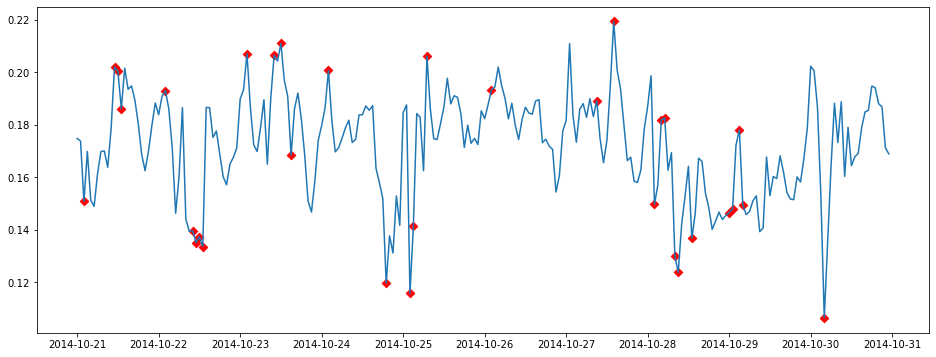

In [32]:
plt.figure(figsize=(16,6))
plt.plot(ctr_df.reset_index().set_index('datetime')['hourly_ctr'])

plt.scatter(outliers.index, outliers, color='r', marker='D')